In [1]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

In [2]:
home = '/store/carroll/col/data/'
out_figs = '/store/carroll/col/figs/'

base_dir =  '/store/carroll/col/data/2025/rccs/'

wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')

# prepare representative single pxs
fp_single_px = '/store/carroll/col/data/2025/rccs/single_pxs.pkl'
with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)

fids = list(single_px.keys())
fids = [fid for fid in fids if 'insitu' in single_px[fid].keys()] # in situ only

In [3]:
# limit to where we have in situ rfl

modeled_rdns = {k: {} for k in fids}
rccs = {k: {} for k in fids}

In [4]:
for fid in fids:
    print(fid)
    
    # load, update config file
    fp_config = glob(os.path.join(base_dir, fid, 'config', '*_isofit.json'))[0]
    config = configs.create_new_config(fp_config)

    # set up forward model, io, inv according to config
    fm = ForwardModel(config) # loads pre-built LUT
    io = IO(config, fm)
    inv = Inversion(config, fm)
    
    target = 'insitu'
    try:
        # load the single pixel representation
        rdn_ = single_px[fid][target]['rdn']
        obs_ = single_px[fid][target]['obs']
        loc_ = single_px[fid][target]['loc']
        geom = Geometry(obs=obs_, loc=loc_)         

        # run isofit per px
        states=inv.invert(rdn_, geom)
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)

        # get single px rcc
        if 'matterhorn' in fid: k = 'matterhorn_lot'
        elif 'snodgrass' in fid: k = 'snodgrass_bus_stop'
        insitu_rfl = np.loadtxt(os.path.join(home, f'2025/insitu/cal_{k}_neon.txt'))[:,1]
        modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, insitu_rfl)
        rcc_ = modeled_rdn/rdn_

        rccs[fid][target] = rcc_
        modeled_rdns[fid][target] = modeled_rdn
        
    except Exception as e:
        print(f"Error for flight {fid}, key {target}: {e}")

INFO:root:Loading config file: /store/carroll/col/data/2025/rccs/NIS01_20250626_174116_snodgrass_busstop_insitu/config/NIS01_20250626_174116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250626_174116_snodgrass_busstop_insitu/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250626_174116_snodgrass_busstop_insitu


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2025/rccs/NIS01_20250627_155921_matterhorn_lot/config/NIS01_20250627_155921_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250627_155921_matterhorn_lot/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250627_155921_matterhorn_lot


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2025/rccs/NIS01_20250628_165939_snodgrass_busstop_insitu/config/NIS01_20250628_165939_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250628_165939_snodgrass_busstop_insitu/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


...

INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2025/rccs/NIS01_20250628_174221_matterhorn_lot/config/NIS01_20250628_174221_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250628_174221_matterhorn_lot/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250628_174221_matterhorn_lot


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2025/rccs/NIS01_20250629_150841_matterhorn_lot/config/NIS01_20250629_150841_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250629_150841_matterhorn_lot/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250629_150841_matterhorn_lot


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


In [5]:
# save all of the rccs

fp_out = os.path.join(base_dir, 'rccs_insitu_20251117.pkl')

# with open(fp_out, 'wb') as f:
#     pickle.dump(rccs, f)

with open(fp_out, 'rb') as f:
    rccs = pickle.load(f)

In [6]:
rccs.keys()

dict_keys(['NIS01_20250626_174116_snodgrass_busstop_insitu', 'NIS01_20250627_155921_matterhorn_lot', 'NIS01_20250628_165939_snodgrass_busstop_insitu', 'NIS01_20250628_170927_snodgrass_busstop_insitu', 'NIS01_20250628_172359_snodgrass_busstop_insitu', 'NIS01_20250628_174221_matterhorn_lot', 'NIS01_20250629_150841_matterhorn_lot'])

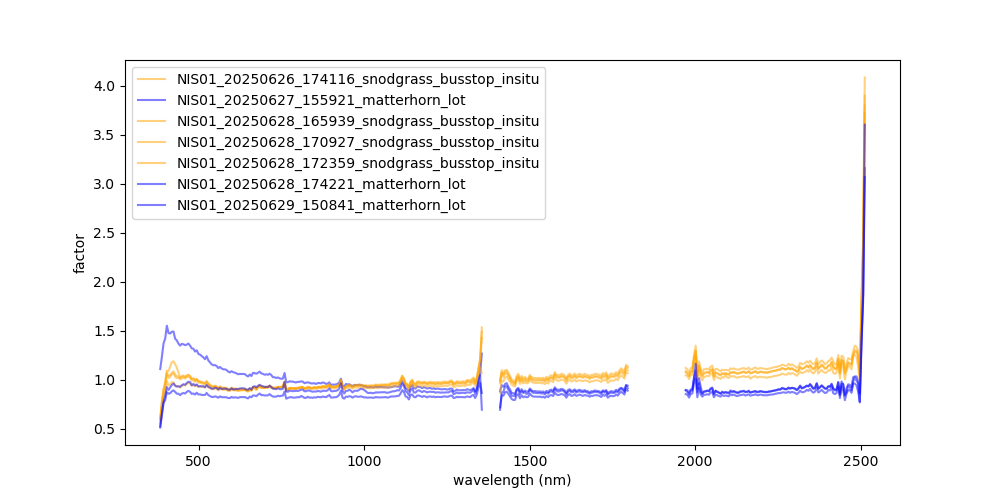

In [7]:
# viz all of the factors together

k = 'insitu'

fig = plt.figure(figsize=(10,5))

for fid in rccs.keys():
    rcc_ = rccs[fid][k]

    if 'matterhorn' in fid: color='blue'
    elif 'snodgrass' in fid: color='orange'
    
    plt.plot(wl_nan, rcc_, label=fid, alpha=0.5, color=color)

# plt.plot(wl_nan, rcc_white_tarp_mean, color='black', label='white tarp mean')

plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.legend()

plt.show()

# plt.savefig(os.path.join(out_figs, f'rccs_2025_insitu_20251117.png'), dpi=300)

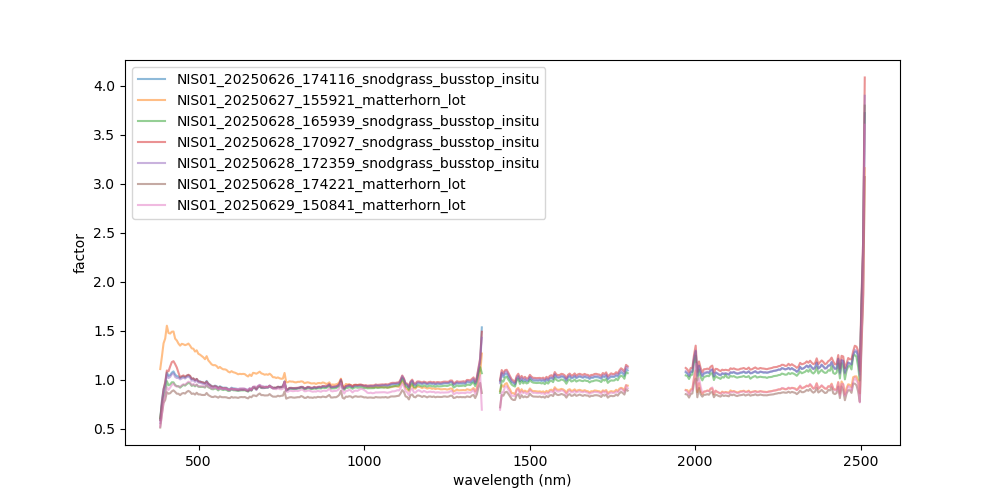

In [8]:
# viz all of the factors together

k = 'insitu'

fig = plt.figure(figsize=(10,5))

for fid in rccs.keys():
    rcc_ = rccs[fid][k]
    plt.plot(wl_nan, rcc_, label=fid, alpha=0.5)

# plt.plot(wl_nan, rcc_white_tarp_mean, color='black', label='white tarp mean')

plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.legend()

plt.show()

# plt.savefig(os.path.join(out_figs, f'rccs_20250829.png'), dpi=300)

In [9]:
# ditch outlier rccs
bad = ['NIS01_20250627_155921_matterhorn_lot', 'NIS01_20250628_170927_snodgrass_busstop_insitu']
rccs_keep = {k: v for k, v in rccs.items() if k not in bad}

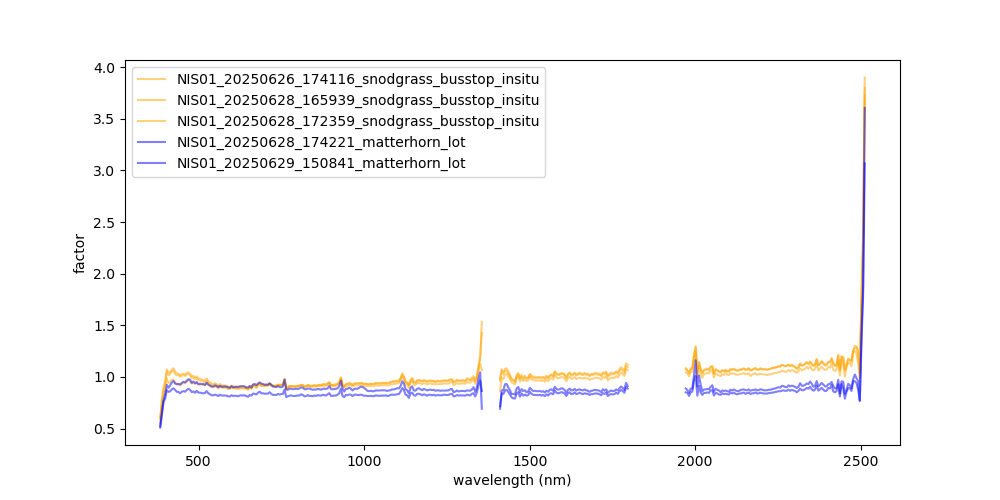

In [10]:
# viz all of the factors together

k = 'insitu'

fig = plt.figure(figsize=(10,5))

for fid in rccs_keep.keys():
    rcc_ = rccs[fid][k]

    if 'matterhorn' in fid: color='blue'
    elif 'snodgrass' in fid: color='orange'
    
    plt.plot(wl_nan, rcc_, label=fid, alpha=0.5, color=color)

# plt.plot(wl_nan, rcc_white_tarp_mean, color='black', label='white tarp mean')

plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.legend()

plt.show()

# plt.savefig(os.path.join(out_figs, f'rccs_2025_insitu_20251117.png'), dpi=300)

In [18]:
# calculate, save mean factors for snodgrass (bright, consistent across days)

# rcc_mean = []

# for fid in rccs_keep.keys():
#     if 'snodgrass' in fid:
#         rcc_ = rccs_keep[fid]['insitu']
#         rcc_mean.append(rcc_)
#     else: pass
# rcc_mean = np.stack(rcc_mean, axis=0)
# rcc_mean = np.mean(rcc_mean, axis=0)

# # save them so can input them later...
fp_out = os.path.join(base_dir, 'rcc_snodgrass_mean_20251117.txt')
# np.savetxt(fp_out, rcc_mean)

with open(fp_out, 'rb') as f:
    rcc_mean_snodgrass = np.loadtxt(f)

In [19]:
# calculate, save mean factors for snodgrass AND matterhorn

# rcc_mean = []

# for fid in rccs_keep.keys():
#     rcc_ = rccs_keep[fid]['insitu']
#     rcc_mean.append(rcc_)
# rcc_mean = np.stack(rcc_mean, axis=0)
# rcc_mean = np.mean(rcc_mean, axis=0)

# # save them so can input them later...
fp_out = os.path.join(base_dir, 'rcc_snodgrass_matterhorn_mean_20251117.txt')
# np.savetxt(fp_out, rcc_mean)

with open(fp_out, 'rb') as f:
    rcc_mean_snodgrass_matterhorn = np.loadtxt(f)

In [21]:
# calculate, save mean factors for matterhorn (comparing trend with snodgrass)

# rcc_mean = []

# for fid in rccs_keep.keys():
#     if 'matterhorn' in fid:
#         rcc_ = rccs_keep[fid]['insitu']
#         rcc_mean.append(rcc_)
#     else: pass
# rcc_mean = np.stack(rcc_mean, axis=0)
# rcc_mean = np.mean(rcc_mean, axis=0)

# # # save them so can input them later...
fp_out = os.path.join(base_dir, 'rcc_matterhorn_mean_20251117.txt')
# np.savetxt(fp_out, rcc_mean)

with open(fp_out, 'rb') as f:
    rcc_mean_matterhorn = np.loadtxt(f)

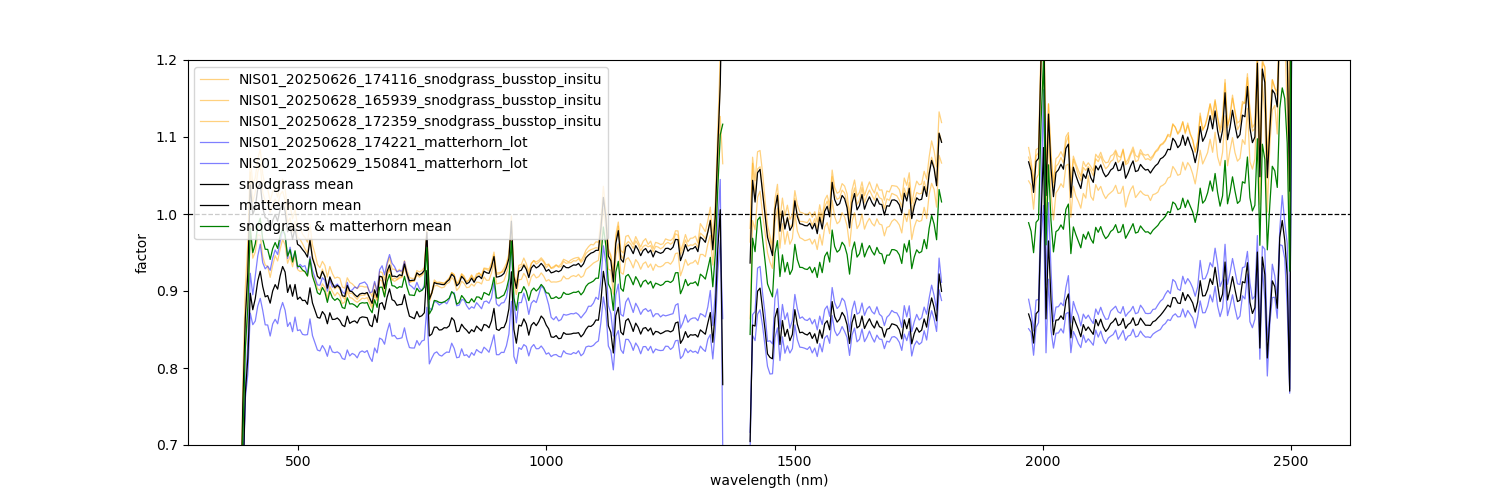

In [22]:
# viz all of the factors together

k = 'insitu'
lw = 0.9

fig = plt.figure(figsize=(15,5))

plt.axhline(y=1, color='black', linestyle='--', lw=lw)

for fid in rccs_keep.keys():
    rcc_ = rccs[fid][k]

    if 'matterhorn' in fid: color='blue'
    elif 'snodgrass' in fid: color='orange'
    
    plt.plot(wl_nan, rcc_, label=fid, alpha=0.5, color=color, lw=lw)

plt.plot(wl_nan, rcc_mean_snodgrass, color='black', label='snodgrass mean', lw=lw)
plt.plot(wl_nan, rcc_mean_matterhorn, color='black', label='matterhorn mean', lw=lw)
plt.plot(wl_nan, rcc_mean_snodgrass_matterhorn, color='green', label='snodgrass & matterhorn mean', lw=lw)


plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.ylim(0.7, 1.2)
plt.legend()

plt.show()

# plt.savefig(os.path.join(out_figs, f'rccs_2025_insitu_mean_20251117.png'), dpi=300)